In [2]:
from google.colab import files
uploaded = files.upload()

Saving olist_orders_dataset.csv to olist_orders_dataset (1).csv


In [3]:
from google.colab import files
uploaded = files.upload()


Saving olist_customers_dataset.csv to olist_customers_dataset.csv


In [4]:
!pip install xgboost shap

In [5]:
import pandas as pd
orders = pd.read_csv('olist_orders_dataset.csv')  # adjust path if using Drive
customers = pd.read_csv('olist_customers_dataset.csv')
print(orders.shape, customers.shape)
orders.head()

(99441, 8) (99441, 5)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [7]:
# Check customers table structure
print("Customers shape:", customers.shape)
print(customers.head())
print()

# Check order_status distribution
print(orders['order_status'].value_counts())
print()

# Check date range
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
print("Earliest order:", orders['order_purchase_timestamp'].min())
print("Latest order:", orders['order_purchase_timestamp'].max())

Customers shape: (99441, 5)
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
proces

In [10]:
# Step 1: Keep only delivered orders (real completed purchases)
delivered = orders[orders['order_status'] == 'delivered'].copy()

# Step 2: Join with customers to get the TRUE person-level ID
delivered = delivered.merge(
    customers[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
)

print("Delivered orders:", delivered.shape)
print("Unique customers (by customer_id):", delivered['customer_id'].nunique())
print("Unique customers (by customer_unique_id):", delivered['customer_unique_id'].nunique())


Delivered orders: (96478, 9)
Unique customers (by customer_id): 96478
Unique customers (by customer_unique_id): 93358


In [13]:
from google.colab import files
uploaded = files.upload()

Saving olist_customers_dataset.csv to olist_customers_dataset (1).csv
Saving olist_geolocation_dataset.csv to olist_geolocation_dataset.csv
Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv
Saving olist_order_payments_dataset.csv to olist_order_payments_dataset.csv
Saving olist_order_reviews_dataset.csv to olist_order_reviews_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset (2).csv
Saving olist_products_dataset.csv to olist_products_dataset.csv
Saving olist_sellers_dataset.csv to olist_sellers_dataset.csv
Saving product_category_name_translation.csv to product_category_name_translation.csv


In [14]:
payments = pd.read_csv('olist_order_payments_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')

print("Payments shape:", payments.shape)
print(payments.head())
print()
print("Order items shape:", order_items.shape)
print(order_items.head())
print()
print("Reviews shape:", reviews.shape)
print(reviews.head())


Payments shape: (103886, 5)
                           order_id  payment_sequential payment_type  \
0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   
2  25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card   
3  ba78997921bbcdc1373bb41e913ab953                   1  credit_card   
4  42fdf880ba16b47b59251dd489d4441a                   1  credit_card   

   payment_installments  payment_value  
0                     8          99.33  
1                     1          24.39  
2                     1          65.71  
3                     8         107.78  
4                     2         128.45  

Order items shape: (112650, 7)
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75          

In [15]:
# Aggregate payments to one row per order (sum payment_value across installments/methods)
order_payments = payments.groupby('order_id').agg(
    payment_value=('payment_value', 'sum'),
    payment_installments_max=('payment_installments', 'max'),
    payment_type_count=('payment_type', 'nunique')
).reset_index()

print("Order payments shape:", order_payments.shape)
print("Unique order_ids in payments:", payments['order_id'].nunique())
order_payments.head()

Order payments shape: (99440, 4)
Unique order_ids in payments: 99440


,order_id,payment_value,payment_installments_max,payment_type_count
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1


In [16]:
# Merge delivered orders with aggregated payments
rfm_base = delivered.merge(order_payments, on='order_id', how='left')

print("RFM base shape:", rfm_base.shape)
print("Missing payment_value:", rfm_base['payment_value'].isna().sum())
rfm_base.head()

RFM base shape: (96478, 12)
Missing payment_value: 1


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,payment_value,payment_installments_max,payment_type_count
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,38.71,1.0,2.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,141.46,1.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,179.12,3.0,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,72.20,1.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,28.62,1.0,1.0


In [17]:
# Drop the single row with missing payment data
rfm_base = rfm_base.dropna(subset=['payment_value'])
print("RFM base shape after dropna:", rfm_base.shape)

RFM base shape after dropna: (96477, 12)


In [18]:
# Set the "snapshot date" — the reference point we calculate recency FROM
# Using 1 day after the last order in the dataset
snapshot_date = rfm_base['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date)

# Build RFM table
rfm = rfm_base.groupby('customer_unique_id').agg(
    recency_days=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('payment_value', 'sum')
).reset_index()

print("RFM table shape:", rfm.shape)
print()
print(rfm.describe())
rfm.head(10)

Snapshot date: 2018-08-30 15:00:37
RFM table shape: (93357, 4)

       recency_days     frequency      monetary
count  93357.000000  93357.000000  93357.000000
mean     237.936673      1.033420    165.198772
std      152.584315      0.209099    226.314579
min        1.000000      1.000000      9.590000
25%      114.000000      1.000000     63.060000
50%      219.000000      1.000000    107.780000
75%      346.000000      1.000000    182.560000
max      695.000000     15.000000  13664.080000


,customer_unique_id,recency_days,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89
5,0004bd2a26a76fe21f786e4fbd80607f,146,1,166.98
6,00050ab1314c0e55a6ca13cf7181fecf,132,1,35.38
7,00053a61a98854899e70ed204dd4bafe,183,1,419.18
8,0005e1862207bf6ccc02e4228effd9a0,543,1,150.12
9,0005ef4cd20d2893f0d9fbd94d3c0d97,170,1,129.76


In [19]:
print("Max purchase timestamp in ALL orders:", orders['order_purchase_timestamp'].max())
print("Max purchase timestamp in DELIVERED orders only:", delivered['order_purchase_timestamp'].max())

Max purchase timestamp in ALL orders: 2018-10-17 17:30:18
Max purchase timestamp in DELIVERED orders only: 2018-08-29 15:00:37


In [20]:
# Step 1: Find each customer's order sequence, ordered by time
customer_orders = rfm_base.sort_values(['customer_unique_id', 'order_purchase_timestamp']).copy()
customer_orders['order_rank'] = customer_orders.groupby('customer_unique_id').cumcount() + 1

# Step 2: Isolate first orders only
first_orders = customer_orders[customer_orders['order_rank'] == 1].copy()

# Step 3: Label — did this customer ever place a 2nd order?
repeat_customer_ids = set(customer_orders[customer_orders['order_rank'] == 2]['customer_unique_id'])
first_orders['made_repeat_purchase'] = first_orders['customer_unique_id'].isin(repeat_customer_ids).astype(int)

print("First-orders table shape:", first_orders.shape)
print()
print("Repeat purchase rate:", first_orders['made_repeat_purchase'].mean())
print(first_orders['made_repeat_purchase'].value_counts())

First-orders table shape: (93357, 14)

Repeat purchase rate: 0.030003106355174225
made_repeat_purchase
0    90556
1     2801
Name: count, dtype: int64


In [21]:
# Get product category + price/freight info per order (an order can have multiple items, so aggregate)
order_items_agg = order_items.groupby('order_id').agg(
    n_items=('order_item_id', 'count'),
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    avg_item_price=('price', 'mean')
).reset_index()

print("Order items aggregated shape:", order_items_agg.shape)
order_items_agg.head()

Order items aggregated shape: (98666, 5)


,order_id,n_items,total_price,total_freight,avg_item_price
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,58.90
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,239.90
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,199.00
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,199.90


In [22]:
# Get review score per order (some orders may have multiple reviews — rare, but handle it)
reviews_agg = reviews.groupby('order_id').agg(
    review_score=('review_score', 'mean')
).reset_index()

print("Reviews aggregated shape:", reviews_agg.shape)
reviews_agg.head()

Reviews aggregated shape: (98673, 2)


,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


In [23]:
# Merge product/price and review data into first_orders
features = first_orders.merge(order_items_agg, on='order_id', how='left')
features = features.merge(reviews_agg, on='order_id', how='left')

print("Features shape after merges:", features.shape)
print("Missing n_items:", features['n_items'].isna().sum())
print("Missing review_score:", features['review_score'].isna().sum())

Features shape after merges: (93357, 19)
Missing n_items: 0
Missing review_score: 617


In [25]:
# Convert remaining date columns to datetime
for col in ['order_delivered_customer_date', 'order_estimated_delivery_date', 'order_approved_at']:
    features[col] = pd.to_datetime(features[col])

# Delivery delay: positive = late, negative = early/on-time
features['delivery_delay_days'] = (
    features['order_delivered_customer_date'] - features['order_estimated_delivery_date']
).dt.days

# Delivery speed: how many days from purchase to actual delivery
features['delivery_speed_days'] = (
    features['order_delivered_customer_date'] - features['order_purchase_timestamp']
).dt.days

# Approval speed: how long Olist took to approve the order
features['approval_speed_hours'] = (
    features['order_approved_at'] - features['order_purchase_timestamp']
).dt.total_seconds() / 3600

# Day of week and month of first purchase
features['purchase_dayofweek'] = features['order_purchase_timestamp'].dt.dayofweek
features['purchase_month'] = features['order_purchase_timestamp'].dt.month

# Flag for missing review, then impute
features['has_review'] = features['review_score'].notna().astype(int)
features['review_score'] = features['review_score'].fillna(features['review_score'].median())

In [26]:
print("Missing delivery_delay_days:", features['delivery_delay_days'].isna().sum())
print("Missing delivery_speed_days:", features['delivery_speed_days'].isna().sum())
print()
print(features[['delivery_delay_days', 'delivery_speed_days', 'approval_speed_hours']].describe())

Missing delivery_delay_days: 8
Missing delivery_speed_days: 8

       delivery_delay_days  delivery_speed_days  approval_speed_hours
count         93349.000000         93349.000000          93343.000000
mean            -11.853325            12.103504             10.303681
std              10.186279             9.583296             20.578992
min            -147.000000             0.000000              0.000000
25%             -17.000000             6.000000              0.215278
50%             -12.000000            10.000000              0.343333
75%              -7.000000            15.000000             14.580694
max             188.000000           209.000000            741.443611


In [27]:
# Drop the 8 rows with missing delivery dates
features = features.dropna(subset=['delivery_delay_days', 'delivery_speed_days', 'approval_speed_hours'])
print("Features shape after dropping nulls:", features.shape)

# Quick check on the extreme delivery delay outlier
print(features.nlargest(3, 'delivery_delay_days')[['order_id', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_delay_days']])

Features shape after dropping nulls: (93335, 25)
                               order_id order_purchase_timestamp  \
85851  1b3190b2dfa9d789e1f14c05b647a14a      2018-02-23 14:57:35   
27092  ca07593549f1816d26a572e06dc1eab6      2017-02-21 23:31:27   
28015  47b40429ed8cce3aee9199792275433f      2018-01-03 09:44:01   

      order_delivered_customer_date order_estimated_delivery_date  \
85851           2018-09-19 23:24:07                    2018-03-15   
27092           2017-09-19 14:36:39                    2017-03-22   
28015           2018-07-13 20:51:31                    2018-01-19   

       delivery_delay_days  
85851                188.0  
27092                181.0  
28015                175.0  


In [28]:
# Load products dataset for category info
products = pd.read_csv('olist_products_dataset.csv')
print("Products shape:", products.shape)
print(products[['product_id', 'product_category_name']].head())

Products shape: (32951, 9)
                         product_id  product_category_name
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer
3  cef67bcfe19066a932b7673e239eb23d                  bebes
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas


In [29]:
# Get English category names
category_translation = pd.read_csv('product_category_name_translation.csv')
print(category_translation.head())

# Merge translation into products
products = products.merge(category_translation, on='product_category_name', how='left')
print()
print("Missing English category names:", products['product_category_name_english'].isna().sum())

    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
3         cama_mesa_banho                bed_bath_table
4        moveis_decoracao               furniture_decor

Missing English category names: 623


In [30]:
# Get category for each order (using the first item if an order has multiple distinct products)
order_category = order_items.merge(products[['product_id', 'product_category_name_english']], on='product_id', how='left')
order_category = order_category.sort_values(['order_id', 'order_item_id']).drop_duplicates(subset='order_id', keep='first')
order_category = order_category[['order_id', 'product_category_name_english']]

print("Order category shape:", order_category.shape)
print("Missing category:", order_category['product_category_name_english'].isna().sum())

# Merge into our features table
features = features.merge(order_category, on='order_id', how='left')
print()
print("Features shape after category merge:", features.shape)
print("Missing category in features:", features['product_category_name_english'].isna().sum())

Order category shape: (98666, 2)
Missing category: 1437

Features shape after category merge: (93335, 26)
Missing category in features: 1333


In [31]:
# Fill missing category with 'unknown' rather than dropping rows
features['product_category_name_english'] = features['product_category_name_english'].fillna('unknown')

# Quick check: how many distinct categories do we have, and what's the distribution look like?
print("Number of categories:", features['product_category_name_english'].nunique())
print()
print(features['product_category_name_english'].value_counts().head(15))

Number of categories: 72

product_category_name_english
bed_bath_table           8729
health_beauty            8353
sports_leisure           7197
computers_accessories    6288
furniture_decor          5925
housewares               5502
watches_gifts            5313
telephony                3988
auto                     3702
toys                     3673
cool_stuff               3468
garden_tools             3331
perfumery                2989
baby                     2692
electronics              2464
Name: count, dtype: int64


In [33]:
print(features.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'payment_value', 'payment_installments_max', 'payment_type_count', 'order_rank', 'made_repeat_purchase', 'n_items', 'total_price', 'total_freight', 'avg_item_price', 'review_score', 'delivery_delay_days', 'delivery_speed_days', 'approval_speed_hours', 'purchase_dayofweek', 'purchase_month', 'has_review', 'product_category_name_english']


In [34]:
# Save to CSV (recency_days was never part of this table, so nothing to drop)
features.to_csv('features_phase1.csv', index=False)

from google.colab import files
files.download('features_phase1.csv')

print("Saved. Shape:", features.shape)
print(features.columns.tolist())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved. Shape: (93335, 26)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'payment_value', 'payment_installments_max', 'payment_type_count', 'order_rank', 'made_repeat_purchase', 'n_items', 'total_price', 'total_freight', 'avg_item_price', 'review_score', 'delivery_delay_days', 'delivery_speed_days', 'approval_speed_hours', 'purchase_dayofweek', 'purchase_month', 'has_review', 'product_category_name_english']


               delay_bucket      mean  count
0           Early (7+ days)  0.031501  73617
3       Very late (7+ days)  0.026580   2784
2  Slightly late (1-7 days)  0.024636   3572
1  On-time (0-7 days early)  0.023874  13362


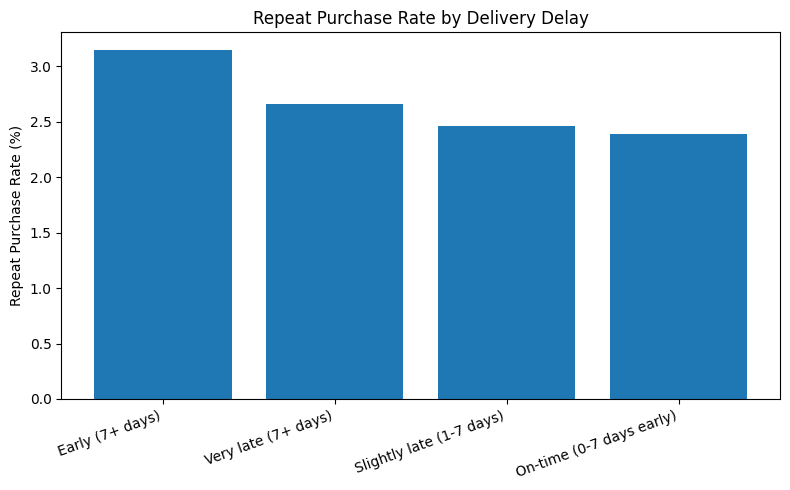

In [35]:
import matplotlib.pyplot as plt

# Bucket delivery delay into readable categories
def delay_bucket(days):
    if days <= -7:
        return 'Early (7+ days)'
    elif days <= 0:
        return 'On-time (0-7 days early)'
    elif days <= 7:
        return 'Slightly late (1-7 days)'
    else:
        return 'Very late (7+ days)'

features['delay_bucket'] = features['delivery_delay_days'].apply(delay_bucket)

repeat_by_delay = features.groupby('delay_bucket')['made_repeat_purchase'].agg(['mean', 'count']).reset_index()
repeat_by_delay = repeat_by_delay.sort_values('mean', ascending=False)
print(repeat_by_delay)

# Plot
plt.figure(figsize=(8, 5))
order = ['Early (7+ days)', 'On-time (0-7 days early)', 'Slightly late (1-7 days)', 'Very late (7+ days)']
plt.bar(repeat_by_delay['delay_bucket'], repeat_by_delay['mean'] * 100)
plt.ylabel('Repeat Purchase Rate (%)')
plt.title('Repeat Purchase Rate by Delivery Delay')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [36]:
# Does delay_bucket correlate with how early/late in the dataset the order happened?
features.groupby('delay_bucket')['order_purchase_timestamp'].agg(['min', 'max', 'median'])

,min,max,median
delay_bucket,,,
Early (7+ days),2016-10-03 16:56:50,2018-08-29 14:18:28,2018-01-08 16:39:36.000
On-time (0-7 days early),2016-10-03 09:44:50,2018-08-29 15:00:37,2018-03-11 21:53:24.000
Slightly late (1-7 days),2016-10-04 18:07:24,2018-08-24 18:26:00,2018-02-21 20:28:33.500
Very late (7+ days),2016-10-04 21:54:52,2018-08-21 09:52:32,2018-02-16 14:19:14.500


In [37]:
# Define a fair comparison cutoff: first order must be at least 180 days before snapshot date
snapshot_date = pd.Timestamp('2018-08-30')
cutoff_date = snapshot_date - pd.Timedelta(days=180)

print("Cutoff date (orders must be before this):", cutoff_date)

features_fair = features[features['order_purchase_timestamp'] <= cutoff_date].copy()
print("Rows before filter:", len(features))
print("Rows after filter:", len(features_fair))
print()
print("Repeat purchase rate (full data):", features['made_repeat_purchase'].mean())
print("Repeat purchase rate (fair window only):", features_fair['made_repeat_purchase'].mean())

Cutoff date (orders must be before this): 2018-03-03 00:00:00
Rows before filter: 93335
Rows after filter: 56019

Repeat purchase rate (full data): 0.029999464295280442
Repeat purchase rate (fair window only): 0.0397186668808797


               delay_bucket      mean  count
0           Early (7+ days)  0.041062  45955
1  On-time (0-7 days early)  0.035085   6242
2  Slightly late (1-7 days)  0.031605   2025
3       Very late (7+ days)  0.030607   1797


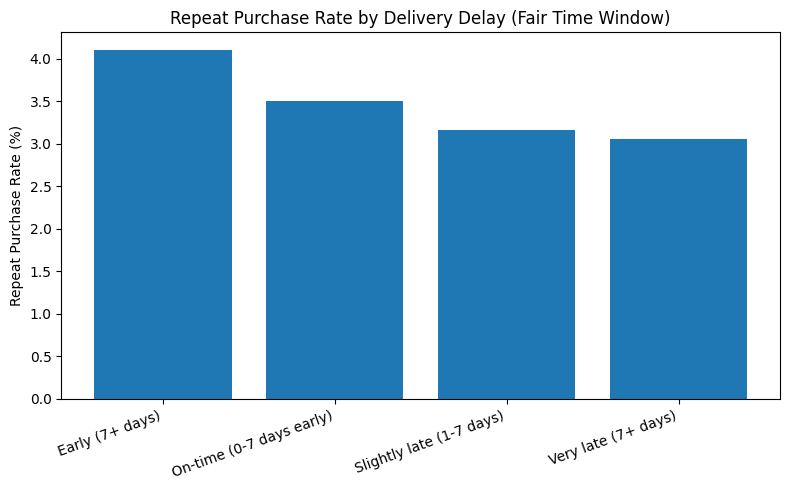

In [38]:
repeat_by_delay_fair = features_fair.groupby('delay_bucket')['made_repeat_purchase'].agg(['mean', 'count']).reset_index()
repeat_by_delay_fair = repeat_by_delay_fair.sort_values('mean', ascending=False)
print(repeat_by_delay_fair)

plt.figure(figsize=(8, 5))
plt.bar(repeat_by_delay_fair['delay_bucket'], repeat_by_delay_fair['mean'] * 100)
plt.ylabel('Repeat Purchase Rate (%)')
plt.title('Repeat Purchase Rate by Delivery Delay (Fair Time Window)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

  price_quartile      mean  count
0    Q1 (Lowest)  0.041696  14006
1             Q2  0.041417  14004
2             Q3  0.038418  14004
3   Q4 (Highest)  0.037344  14005


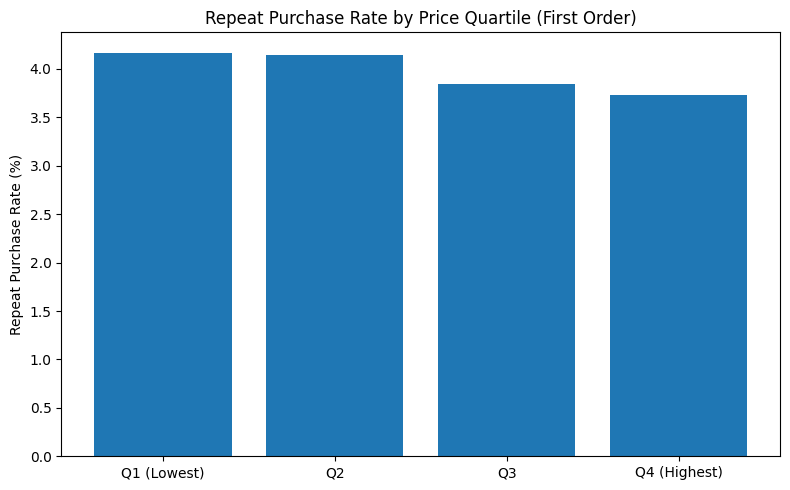

In [39]:
# Price quartile vs repeat purchase rate
features_fair['price_quartile'] = pd.qcut(features_fair['payment_value'], q=4, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'])

repeat_by_price = features_fair.groupby('price_quartile', observed=True)['made_repeat_purchase'].agg(['mean', 'count']).reset_index()
print(repeat_by_price)

plt.figure(figsize=(8, 5))
plt.bar(repeat_by_price['price_quartile'].astype(str), repeat_by_price['mean'] * 100)
plt.ylabel('Repeat Purchase Rate (%)')
plt.title('Repeat Purchase Rate by Price Quartile (First Order)')
plt.tight_layout()
plt.show()

Top 10 categories by repeat rate:
   product_category_name_english      mean  count
44               home_appliances  0.089928    278
28      fashion_bags_accessories  0.071057   1154
7                 bed_bath_table  0.060074   5410
40         furniture_living_room  0.059574    235
39               furniture_decor  0.058307   3756
47                  home_confort  0.053232    263
65                sports_leisure  0.049022   4549
60                      pet_shop  0.044525    831
15         computers_accessories  0.041264   3829
43                 health_beauty  0.040528   4392

Bottom 10 categories by repeat rate:
   product_category_name_english      mean  count
68                     telephony  0.028725   2611
63              small_appliances  0.027322    366
5                           auto  0.026758   1906
26                   electronics  0.026185   1413
66                    stationery  0.026163   1376
53           luggage_accessories  0.025605    703
56           musical_instrum

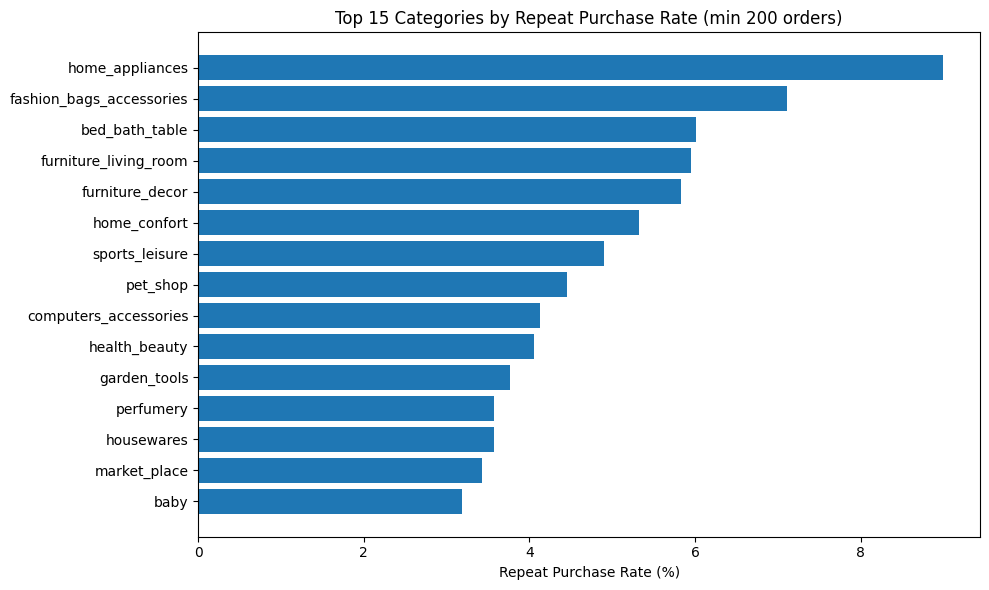

In [40]:
# Repeat purchase rate by category (only categories with meaningful sample size)
category_stats = features_fair.groupby('product_category_name_english')['made_repeat_purchase'].agg(['mean', 'count']).reset_index()
category_stats = category_stats[category_stats['count'] >= 200]  # filter out tiny categories (noisy estimates)
category_stats = category_stats.sort_values('mean', ascending=False)

print("Top 10 categories by repeat rate:")
print(category_stats.head(10))
print()
print("Bottom 10 categories by repeat rate:")
print(category_stats.tail(10))

# Plot top 15
plt.figure(figsize=(10, 6))
top15 = category_stats.head(15).sort_values('mean')
plt.barh(top15['product_category_name_english'], top15['mean'] * 100)
plt.xlabel('Repeat Purchase Rate (%)')
plt.title('Top 15 Categories by Repeat Purchase Rate (min 200 orders)')
plt.tight_layout()
plt.show()

   review_score      mean  count
0           1.0  0.035248   5589
1           1.5  1.000000      3
2           2.0  0.034250   1781
3           2.5  0.533333     15
4           3.0  0.037410   4865
5           3.5  0.800000     10
6           4.0  0.035695  11150
7           4.5  0.857143     21
8           5.0  0.041430  32585


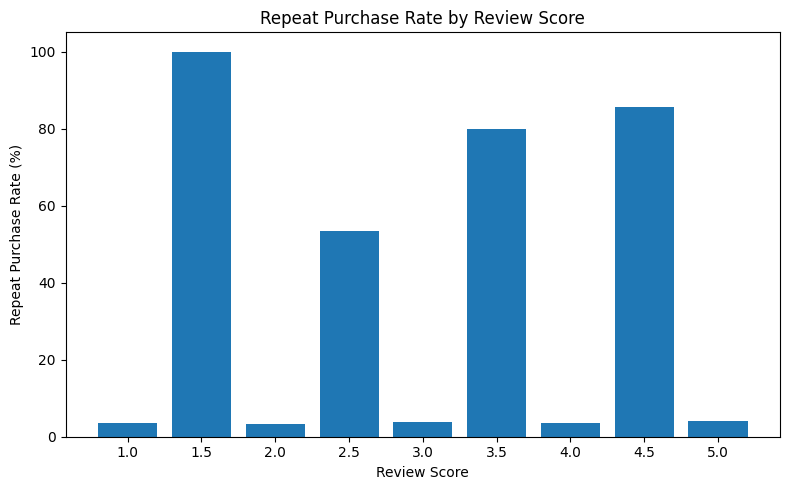

In [41]:
# Repeat purchase rate by review score
repeat_by_review = features_fair.groupby('review_score')['made_repeat_purchase'].agg(['mean', 'count']).reset_index()
print(repeat_by_review)

plt.figure(figsize=(8, 5))
plt.bar(repeat_by_review['review_score'].astype(str), repeat_by_review['mean'] * 100)
plt.xlabel('Review Score')
plt.ylabel('Repeat Purchase Rate (%)')
plt.title('Repeat Purchase Rate by Review Score')
plt.tight_layout()
plt.show()

   review_score_rounded      mean  count
0                     1  0.035248   5589
1                     2  0.040022   1799
2                     3  0.037410   4865
3                     4  0.037921  11181
4                     5  0.041430  32585


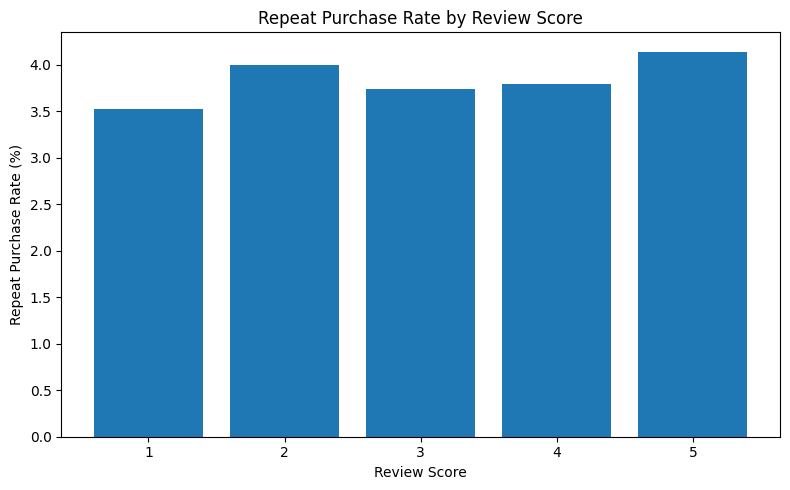

In [42]:
# Round half-point scores (artifacts of multi-review averaging) to nearest integer
features_fair['review_score_rounded'] = features_fair['review_score'].round().astype(int)

repeat_by_review_clean = features_fair.groupby('review_score_rounded')['made_repeat_purchase'].agg(['mean', 'count']).reset_index()
print(repeat_by_review_clean)

plt.figure(figsize=(8, 5))
plt.bar(repeat_by_review_clean['review_score_rounded'].astype(str), repeat_by_review_clean['mean'] * 100)
plt.xlabel('Review Score')
plt.ylabel('Repeat Purchase Rate (%)')
plt.title('Repeat Purchase Rate by Review Score')
plt.tight_layout()
plt.show()

made_repeat_purchase
0    53794
1     2225
Name: count, dtype: int64

Repeat purchase rate: 3.97%


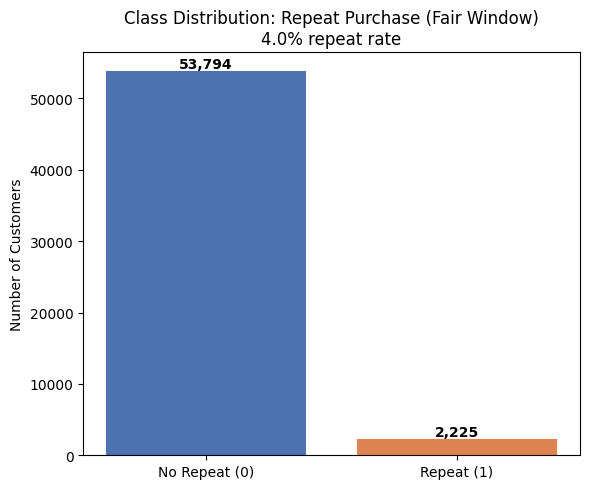

In [43]:
# Class imbalance visualization
imbalance = features_fair['made_repeat_purchase'].value_counts()
print(imbalance)
print()
print(f"Repeat purchase rate: {features_fair['made_repeat_purchase'].mean()*100:.2f}%")

plt.figure(figsize=(6, 5))
plt.bar(['No Repeat (0)', 'Repeat (1)'], imbalance.values, color=['#4C72B0', '#DD8452'])
plt.ylabel('Number of Customers')
plt.title(f'Class Distribution: Repeat Purchase (Fair Window)\n{features_fair["made_repeat_purchase"].mean()*100:.1f}% repeat rate')
for i, v in enumerate(imbalance.values):
    plt.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [44]:
# Save the EDA-ready, fair-window dataset
features_fair.to_csv('features_fair.csv', index=False)

from google.colab import files
files.download('features_fair.csv')

print("Saved. Shape:", features_fair.shape)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved. Shape: (56019, 29)


In [45]:
print(features_fair.dtypes)
print()
print(features_fair.shape)

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date             object
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
customer_unique_id                       object
payment_value                           float64
payment_installments_max                float64
payment_type_count                      float64
order_rank                                int64
made_repeat_purchase                      int64
n_items                                   int64
total_price                             float64
total_freight                           float64
avg_item_price                          float64
review_score                            float64
delivery_delay_days                     float64
delivery_speed_days                     

In [46]:
# Bucket rare categories into 'other' to keep one-hot encoding manageable
category_counts = features_fair['product_category_name_english'].value_counts()
top_categories = category_counts[category_counts >= 500].index  # keep categories with 500+ orders
print(f"Categories kept individually: {len(top_categories)}")
print(f"Categories bucketed into 'other': {features_fair['product_category_name_english'].nunique() - len(top_categories)}")

features_fair['category_grouped'] = features_fair['product_category_name_english'].apply(
    lambda x: x if x in top_categories else 'other'
)
print()
print(features_fair['category_grouped'].value_counts())

Categories kept individually: 22
Categories bucketed into 'other': 50

category_grouped
bed_bath_table              5410
other                       4919
sports_leisure              4549
health_beauty               4392
computers_accessories       3829
furniture_decor             3756
housewares                  2942
watches_gifts               2646
toys                        2640
telephony                   2611
cool_stuff                  2583
garden_tools                2313
perfumery                   1987
auto                        1906
baby                        1508
electronics                 1413
stationery                  1376
fashion_bags_accessories    1154
unknown                     1023
pet_shop                     831
office_furniture             787
consoles_games               741
luggage_accessories          703
Name: count, dtype: int64


In [47]:
# Build final feature set
model_columns = [
    'payment_value', 'payment_installments_max', 'payment_type_count',
    'n_items', 'total_price', 'total_freight', 'avg_item_price',
    'delivery_delay_days', 'delivery_speed_days', 'approval_speed_hours',
    'purchase_dayofweek', 'purchase_month', 'has_review', 'review_score_rounded',
    'category_grouped'
]

model_df = features_fair[model_columns + ['made_repeat_purchase']].copy()

# One-hot encode category_grouped
model_df = pd.get_dummies(model_df, columns=['category_grouped'], drop_first=True)

print("Final modeling table shape:", model_df.shape)
print()
print(model_df.dtypes)

Final modeling table shape: (56019, 37)

payment_value                                float64
payment_installments_max                     float64
payment_type_count                           float64
n_items                                        int64
total_price                                  float64
total_freight                                float64
avg_item_price                               float64
delivery_delay_days                          float64
delivery_speed_days                          float64
approval_speed_hours                         float64
purchase_dayofweek                             int32
purchase_month                                 int32
has_review                                     int64
review_score_rounded                           int64
made_repeat_purchase                           int64
category_grouped_baby                           bool
category_grouped_bed_bath_table                 bool
category_grouped_computers_accessories          bool
categ

In [48]:
from sklearn.model_selection import train_test_split

X = model_df.drop(columns=['made_repeat_purchase'])
y = model_df['made_repeat_purchase']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Repeat rate:", y_train.mean())
print("Test shape:", X_test.shape, "Repeat rate:", y_test.mean())

Train shape: (44815, 36) Repeat rate: 0.0397188441370077
Test shape: (11204, 36) Repeat rate: 0.03971795787218851


In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix

# Scale features (logistic regression is sensitive to feature scale; tree models later won't need this)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline logistic regression with class weighting
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred))
print()
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("PR-AUC (Average Precision):", average_precision_score(y_test, y_pred_proba))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.58      0.73     10759
           1       0.05      0.56      0.10       445

    accuracy                           0.58     11204
   macro avg       0.51      0.57      0.41     11204
weighted avg       0.93      0.58      0.70     11204


ROC-AUC: 0.6022647357686431
PR-AUC (Average Precision): 0.05882993742717878

Confusion Matrix:
[[6260 4499]
 [ 195  250]]


In [50]:
import xgboost as xgb

# XGBoost handles imbalance via scale_pos_weight (ratio of negative to positive class)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)  # tree models don't need scaling, use unscaled X_train

y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred_xgb))
print()
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb))
print("PR-AUC (Average Precision):", average_precision_score(y_test, y_pred_proba_xgb))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

scale_pos_weight: 24.176966292134832
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.73      0.83     10759
           1       0.06      0.41      0.10       445

    accuracy                           0.72     11204
   macro avg       0.51      0.57      0.47     11204
weighted avg       0.93      0.72      0.80     11204


ROC-AUC: 0.6022457289481187
PR-AUC (Average Precision): 0.06125530677331761

Confusion Matrix:
[[7869 2890]
 [ 262  183]]


In [51]:
import pandas as pd

importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance.head(15))

                                      feature  importance
15            category_grouped_bed_bath_table    0.061218
21           category_grouped_furniture_decor    0.057102
30            category_grouped_sports_leisure    0.043166
18                category_grouped_cool_stuff    0.042877
1                    payment_installments_max    0.037953
20  category_grouped_fashion_bags_accessories    0.035916
32                 category_grouped_telephony    0.032536
35             category_grouped_watches_gifts    0.032099
6                              avg_item_price    0.030647
11                             purchase_month    0.029088
4                                 total_price    0.028779
25       category_grouped_luggage_accessories    0.028743
19               category_grouped_electronics    0.028504
29                  category_grouped_pet_shop    0.027775
0                               payment_value    0.027520


In [52]:
# Target encoding for category: replace each category with its TRAIN-SET repeat rate
# (must compute this from train only, to avoid leaking test-set info)
category_target_means = X_train.join(y_train).groupby(
    features_fair.loc[X_train.index, 'category_grouped']
)['made_repeat_purchase'].mean()

print(category_target_means.sort_values(ascending=False))

category_grouped
fashion_bags_accessories    0.066667
bed_bath_table              0.060987
furniture_decor             0.060707
sports_leisure              0.050847
health_beauty               0.041833
computers_accessories       0.040875
other                       0.039713
pet_shop                    0.038922
garden_tools                0.037968
housewares                  0.034734
perfumery                   0.032746
baby                        0.031509
luggage_accessories         0.029877
unknown                     0.029691
toys                        0.029356
telephony                   0.028447
office_furniture            0.028346
watches_gifts               0.028020
auto                        0.026508
electronics                 0.025939
stationery                  0.025501
cool_stuff                  0.020428
consoles_games              0.019298
Name: made_repeat_purchase, dtype: float64


In [53]:
# Rebuild a version of the modeling table using target encoding instead of one-hot for category

# Step 1: Split BEFORE encoding, to prevent leakage
from sklearn.model_selection import train_test_split

base_cols = [
    'payment_value', 'payment_installments_max', 'payment_type_count',
    'n_items', 'total_price', 'total_freight', 'avg_item_price',
    'delivery_delay_days', 'delivery_speed_days', 'approval_speed_hours',
    'purchase_dayofweek', 'purchase_month', 'has_review', 'review_score_rounded',
    'category_grouped', 'made_repeat_purchase'
]

df2 = features_fair[base_cols].copy()

train_idx, test_idx = train_test_split(
    df2.index, test_size=0.2, random_state=42, stratify=df2['made_repeat_purchase']
)

train_df = df2.loc[train_idx].copy()
test_df = df2.loc[test_idx].copy()

# Step 2: Compute category target-encoding from TRAIN ONLY
category_means = train_df.groupby('category_grouped')['made_repeat_purchase'].mean()
global_mean = train_df['made_repeat_purchase'].mean()

# Step 3: Apply to both sets (unseen categories in test, if any, get the global mean as fallback)
train_df['category_target_enc'] = train_df['category_grouped'].map(category_means)
test_df['category_target_enc'] = test_df['category_grouped'].map(category_means).fillna(global_mean)

# Step 4: Drop the original category column, keep the encoded version
train_df = train_df.drop(columns=['category_grouped'])
test_df = test_df.drop(columns=['category_grouped'])

X_train2 = train_df.drop(columns=['made_repeat_purchase'])
y_train2 = train_df['made_repeat_purchase']
X_test2 = test_df.drop(columns=['made_repeat_purchase'])
y_test2 = test_df['made_repeat_purchase']

print("X_train2 shape:", X_train2.shape)
print(X_train2.columns.tolist())

X_train2 shape: (44815, 15)
['payment_value', 'payment_installments_max', 'payment_type_count', 'n_items', 'total_price', 'total_freight', 'avg_item_price', 'delivery_delay_days', 'delivery_speed_days', 'approval_speed_hours', 'purchase_dayofweek', 'purchase_month', 'has_review', 'review_score_rounded', 'category_target_enc']


In [54]:
scale_pos_weight2 = (y_train2 == 0).sum() / (y_train2 == 1).sum()

xgb_model2 = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight2,
    eval_metric='logloss',
    random_state=42
)

xgb_model2.fit(X_train2, y_train2)

y_pred2 = xgb_model2.predict(X_test2)
y_pred_proba2 = xgb_model2.predict_proba(X_test2)[:, 1]

print("Classification Report:")
print(classification_report(y_test2, y_pred2))
print()
print("ROC-AUC:", roc_auc_score(y_test2, y_pred_proba2))
print("PR-AUC (Average Precision):", average_precision_score(y_test2, y_pred_proba2))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test2, y_pred2))

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.71      0.82     10759
           1       0.06      0.47      0.11       445

    accuracy                           0.70     11204
   macro avg       0.52      0.59      0.46     11204
weighted avg       0.93      0.70      0.79     11204


ROC-AUC: 0.6053812277361728
PR-AUC (Average Precision): 0.06266833243898406

Confusion Matrix:
[[7594 3165]
 [ 237  208]]


In [55]:
# Get customer state for each first order
state_lookup = features_fair[['customer_unique_id']].merge(
    customers[['customer_unique_id', 'customer_state']].drop_duplicates(subset='customer_unique_id'),
    on='customer_unique_id',
    how='left'
)

print("Missing state:", state_lookup['customer_state'].isna().sum())
print()
print(state_lookup['customer_state'].value_counts().head(10))

Missing state: 0

customer_state
SP    22231
RJ     7555
MG     6759
RS     3263
PR     2858
SC     2188
BA     1928
ES     1199
GO     1188
DF     1165
Name: count, dtype: int64


In [56]:
# Add customer_state to our working dataframe
df3 = df2.copy()
df3['customer_state'] = state_lookup['customer_state'].values

print("Missing state in df3:", df3['customer_state'].isna().sum())

# Re-split (same random_state, so train/test split stays consistent with before)
train_df3 = df3.loc[train_idx].copy()
test_df3 = df3.loc[test_idx].copy()

# Target-encode state using TRAIN ONLY
state_means = train_df3.groupby('customer_state')['made_repeat_purchase'].mean()
global_mean3 = train_df3['made_repeat_purchase'].mean()

train_df3['state_target_enc'] = train_df3['customer_state'].map(state_means)
test_df3['state_target_enc'] = test_df3['customer_state'].map(state_means).fillna(global_mean3)

# Also re-encode category the same way (consistent with before)
category_means3 = train_df3.groupby('category_grouped')['made_repeat_purchase'].mean()
train_df3['category_target_enc'] = train_df3['category_grouped'].map(category_means3)
test_df3['category_target_enc'] = test_df3['category_grouped'].map(category_means3).fillna(global_mean3)

train_df3 = train_df3.drop(columns=['category_grouped', 'customer_state'])
test_df3 = test_df3.drop(columns=['category_grouped', 'customer_state'])

X_train3 = train_df3.drop(columns=['made_repeat_purchase'])
y_train3 = train_df3['made_repeat_purchase']
X_test3 = test_df3.drop(columns=['made_repeat_purchase'])
y_test3 = test_df3['made_repeat_purchase']

print("X_train3 shape:", X_train3.shape)
print(X_train3.columns.tolist())

Missing state in df3: 0
X_train3 shape: (44815, 16)
['payment_value', 'payment_installments_max', 'payment_type_count', 'n_items', 'total_price', 'total_freight', 'avg_item_price', 'delivery_delay_days', 'delivery_speed_days', 'approval_speed_hours', 'purchase_dayofweek', 'purchase_month', 'has_review', 'review_score_rounded', 'state_target_enc', 'category_target_enc']


In [57]:
scale_pos_weight3 = (y_train3 == 0).sum() / (y_train3 == 1).sum()

xgb_model3 = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight3,
    eval_metric='logloss',
    random_state=42
)

xgb_model3.fit(X_train3, y_train3)

y_pred3 = xgb_model3.predict(X_test3)
y_pred_proba3 = xgb_model3.predict_proba(X_test3)[:, 1]

print("Classification Report:")
print(classification_report(y_test3, y_pred3))
print()
print("ROC-AUC:", roc_auc_score(y_test3, y_pred_proba3))
print("PR-AUC (Average Precision):", average_precision_score(y_test3, y_pred_proba3))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test3, y_pred3))

# Feature importance check
importance3 = pd.DataFrame({
    'feature': X_train3.columns,
    'importance': xgb_model3.feature_importances_
}).sort_values('importance', ascending=False)
print()
print(importance3)

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.71      0.82     10759
           1       0.06      0.48      0.11       445

    accuracy                           0.70     11204
   macro avg       0.52      0.59      0.46     11204
weighted avg       0.93      0.70      0.79     11204


ROC-AUC: 0.6063165303989029
PR-AUC (Average Precision): 0.06567145669793382

Confusion Matrix:
[[7595 3164]
 [ 233  212]]

                     feature  importance
15       category_target_enc    0.118345
1   payment_installments_max    0.080216
6             avg_item_price    0.071911
14          state_target_enc    0.067294
11            purchase_month    0.063313
0              payment_value    0.059933
4                total_price    0.059306
13      review_score_rounded    0.057698
9       approval_speed_hours    0.057298
5              total_freight    0.055734
2         payment_type_count    0.054863
12                has_review    0.

In [58]:
import joblib

# Save the trained model
joblib.dump(xgb_model3, 'churn_model.pkl')

# Save the encoding lookups (as dictionaries, easy to reload)
category_means3.to_dict()
state_means3_dict = state_means.to_dict()
category_means3_dict = category_means3.to_dict()

import json
with open('category_encoding.json', 'w') as f:
    json.dump(category_means3_dict, f)

with open('state_encoding.json', 'w') as f:
    json.dump(state_means3_dict, f)

# Save the global mean (fallback for unseen categories/states)
with open('global_mean.json', 'w') as f:
    json.dump({'global_mean': global_mean3}, f)

# Save the exact feature column order (critical — model expects columns in this exact order)
feature_columns = X_train3.columns.tolist()
with open('feature_columns.json', 'w') as f:
    json.dump(feature_columns, f)

print("Saved: churn_model.pkl, category_encoding.json, state_encoding.json, global_mean.json, feature_columns.json")

Saved: churn_model.pkl, category_encoding.json, state_encoding.json, global_mean.json, feature_columns.json


In [59]:
from google.colab import files

for fname in ['churn_model.pkl', 'category_encoding.json', 'state_encoding.json', 'global_mean.json', 'feature_columns.json']:
    files.download(fname)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
print(category_means3_dict)
print()
print(state_means3_dict)
print()
print(global_mean3)

{'auto': 0.026507620941020542, 'baby': 0.03150912106135987, 'bed_bath_table': 0.06098696461824953, 'computers_accessories': 0.040875442549082715, 'consoles_games': 0.01929824561403509, 'cool_stuff': 0.020428015564202335, 'electronics': 0.0259391771019678, 'fashion_bags_accessories': 0.06666666666666667, 'furniture_decor': 0.06070713809206137, 'garden_tools': 0.03796791443850268, 'health_beauty': 0.04183266932270916, 'housewares': 0.034734133790737566, 'luggage_accessories': 0.029876977152899824, 'office_furniture': 0.028346456692913385, 'other': 0.03971304125032027, 'perfumery': 0.0327455919395466, 'pet_shop': 0.038922155688622756, 'sports_leisure': 0.05084745762711865, 'stationery': 0.025500910746812388, 'telephony': 0.02844744455159113, 'toys': 0.029356060606060608, 'unknown': 0.029691211401425176, 'watches_gifts': 0.028020211299954065}

{'AC': 0.06818181818181818, 'AL': 0.03, 'AM': 0.0410958904109589, 'AP': 0.03125, 'BA': 0.03769968051118211, 'CE': 0.022187004754358162, 'DF': 0.0362

In [64]:
from google.colab import files

for fname in ['churn_model.pkl', 'category_encoding.json', 'state_encoding.json', 'global_mean.json', 'feature_columns.json']:
    files.download(fname)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import json

with open('category_encoding.json', 'w') as f:
    json.dump(category_means3_dict, f)

with open('state_encoding.json', 'w') as f:
    json.dump(state_means3_dict, f)

with open('global_mean.json', 'w') as f:
    json.dump({'global_mean': global_mean3}, f)

with open('feature_columns.json', 'w') as f:
    json.dump(feature_columns, f)

from google.colab import files
for fname in ['category_encoding.json', 'state_encoding.json', 'global_mean.json', 'feature_columns.json']:
    files.download(fname)

NameError: name 'category_means3_dict' is not defined